# Error Analysis

The previous notebooks measured how often the models succeed. This notebook looks at where and why they fail, using the predictions saved by notebooks 02 to 04, so no model is trained or re-run here. We first break Recall@1 down by characteristics of the questions and answers, then check how far away the correct answer was when a model was wrong, and finally read representative examples of correct answers, near misses, failures and refusals.

In [1]:
# Work from the repository root so that `src` can be imported and the data paths resolve.
import os, sys, warnings
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
warnings.filterwarnings("ignore")

import pandas as pd
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 200)
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
import json, textwrap
import numpy as np
from transformers import AutoTokenizer, logging as hf_logging
hf_logging.set_verbosity_error(); hf_logging.disable_progress_bar()
from src.config import BASE_MODEL, PROCESSED_DIR, RESULTS_DIR, SEED

FINAL = json.load(open(RESULTS_DIR / "final_model_choice.json"))["final_model"].split("/")[-1]
EXPERIMENTS = {"E1_tfidf": "TF-IDF", "E2_pretrained": "pretrained", FINAL: "fine-tuned (final)"}
pred = {(e, s): pd.read_csv(RESULTS_DIR / "experiments" / e / f"predictions_{s}.csv")
        for e in EXPERIMENTS for s in ["val", "test", "paraphrase"]}
records = pd.read_csv(PROCESSED_DIR / "saq_clean.csv")
print("final model:", FINAL)

final model: E5_bs64_seed42


## Overview of the Results

Before looking for errors, it is worth recalling the overall scores of the three main models, since the rest of this notebook explains them. The chart shows Recall@1 on the validation set, the test set and the 40 paraphrased questions.

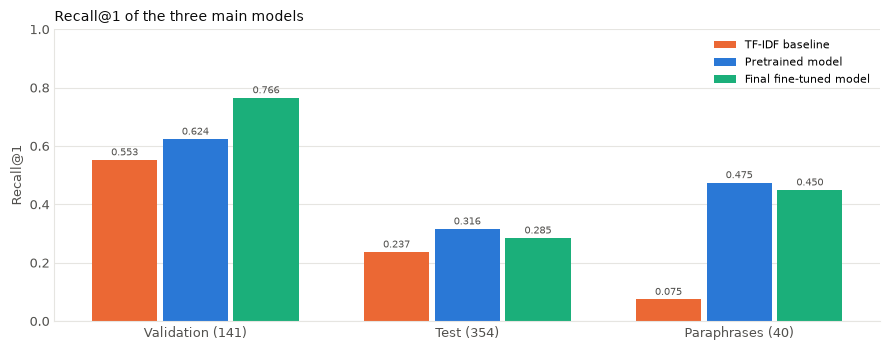

In [2]:
import matplotlib.pyplot as plt
BLUE, ORANGE, AQUA, YELLOW, LIGHT = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#c3c2b7"
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e6e5e1"

def tidy(ax, grid_axis="y"):
    ax.grid(axis=grid_axis, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ["top", "right", "left" if grid_axis == "x" else "top"]:
        ax.spines[side].set_visible(False)
    for side in ["left", "bottom"]:
        ax.spines[side].set_color(GRID)
    ax.tick_params(colors=INK2, labelsize=9, length=0)

# Recall@1 of the TF-IDF baseline, the pretrained model and the final model on each set of questions.
series = [("E1_tfidf", "TF-IDF baseline", ORANGE), ("E2_pretrained", "Pretrained model", BLUE), (FINAL, "Final fine-tuned model", AQUA)]
sets = [("val", "Validation (141)"), ("test", "Test (354)"), ("paraphrase", "Paraphrases (40)")]
x = np.arange(len(sets))
fig, ax = plt.subplots(figsize=(9, 3.6))
for k, (name, label, color) in enumerate(series):
    values = [pred[(name, s)].correct_at_1.mean() for s, _ in sets]
    ax.bar(x + (k - 1) * 0.26, values, width=0.24, color=color, label=label)
    for xi, v in zip(x, values):
        ax.text(xi + (k - 1) * 0.26, v + 0.015, f"{v:.3f}", ha="center", fontsize=7.5, color=INK2)
ax.set_xticks(x, [label for _, label in sets], fontsize=9)
ax.set_ylim(0, 1); ax.set_ylabel("Recall@1", fontsize=9, color=INK2)
ax.legend(frameon=False, fontsize=8, loc="upper right")
ax.set_title("Recall@1 of the three main models", loc="left", fontsize=10, color=INK)
tidy(ax, "y")
fig.tight_layout(); fig.savefig(RESULTS_DIR / "figures" / "retrieval_comparison.png", dpi=200); plt.show()

The fine-tuned model is clearly best on the validation set, but on the test set it falls slightly below the pretrained model, and on the paraphrases the two embedding models are close while TF-IDF is far behind. The rest of this notebook looks for the reasons behind this pattern.

## Recall@1 by Group

Overall scores can hide large differences between groups of questions, so we compute Recall@1 separately by country, specialty, question length, answer length and question style for the TF-IDF baseline, the pretrained model and the final model. Answer length is measured in model tokens, and a question counts as exam-style when it starts with words such as "List", "Define" or "Complications". The first table covers the test set and the second the validation set, and the cell after them shows how long the test answers are in each country and specialty.

In [3]:
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
EXAM_STYLE = (r"^(list|define|discuss|describe|outline|write|name|mention|state|enumerate|give|classify|explain|"
              r"differentiate|compare|what are the|complications|management|investigations|indications|causes)")
rows = []
for split in ["val", "test"]:
    base = records[records.split == split].reset_index(drop=True)
    tokens = np.array([len(t) for t in tokenizer(base.answer.tolist(), truncation=False, verbose=False)["input_ids"]])
    groups = {
        "all": pd.Series("all", index=base.index),
        "country": base.country,
        "specialty": base.specialty.where(base.specialty.isin(["General_Surgery", "Pediatrics", "Internal_Medicine",
                                                                "Obstetrics_and_Gynecology"]), "Other/none"),
        "question length": pd.cut(base.question.str.split().str.len(), [0, 5, 12, 20, 1000],
                                  labels=["1-5 words", "6-12 words", "13-20 words", ">20 words"]),
        "answer length": pd.cut(tokens, [0, 50, 250, 100000], labels=["<=50 tokens", "51-250 tokens", ">250 tokens"]),
        "question style": pd.Series(np.where(base.question.str.strip().str.lower().str.match(EXAM_STYLE),
                                             "exam-style / list prompt", "other"), index=base.index),
    }
    for e, label in EXPERIMENTS.items():
        base[label] = base.id.map(dict(zip(pred[(e, split)].id, pred[(e, split)].correct_at_1)))
    for group, values in groups.items():
        for value, part in base.groupby(pd.Series(values, index=base.index), observed=True):
            rows.append({"split": split, "group": group, "value": str(value), "questions": len(part),
                         **{label: round(part[label].mean(), 3) for label in EXPERIMENTS.values()}})
breakdown = pd.DataFrame(rows)
(RESULTS_DIR / "error_analysis").mkdir(parents=True, exist_ok=True)
breakdown.to_csv(RESULTS_DIR / "error_analysis" / "breakdown.csv", index=False)
breakdown[breakdown.split == "test"]

,split,group,value,questions,TF-IDF,pretrained,fine-tuned (final)
11,test,all,all,354,0.237,0.316,0.285
12,test,country,KE,190,0.153,0.184,0.158
13,test,country,MW,118,0.178,0.271,0.237
14,test,country,NG,46,0.739,0.978,0.935
15,test,specialty,General_Surgery,175,0.143,0.177,0.160
16,test,specialty,Internal_Medicine,53,0.057,0.113,0.057
17,test,specialty,Obstetrics_and_Gynecology,37,0.784,1.000,0.973
18,test,specialty,Other/none,33,0.303,0.455,0.424
19,test,specialty,Pediatrics,56,0.304,0.411,0.357
20,test,question length,1-5 words,92,0.174,0.239,0.217


In [4]:
breakdown[breakdown.split == 'val']

,split,group,value,questions,TF-IDF,pretrained,fine-tuned (final)
0,val,all,all,141,0.553,0.624,0.766
1,val,country,NG,141,0.553,0.624,0.766
2,val,specialty,Other/none,141,0.553,0.624,0.766
3,val,question length,6-12 words,55,0.491,0.491,0.764
4,val,question length,13-20 words,67,0.612,0.716,0.806
5,val,question length,>20 words,19,0.526,0.684,0.632
6,val,answer length,<=50 tokens,85,0.482,0.600,0.765
7,val,answer length,51-250 tokens,55,0.655,0.655,0.764
8,val,answer length,>250 tokens,1,1.000,1.000,1.000
9,val,question style,exam-style / list prompt,46,0.435,0.652,0.739


In [5]:
# Median answer length in model tokens for each country and specialty in the test set.
test_records = records[records.split == "test"].copy()
test_records["answer_tokens"] = [len(t) for t in tokenizer(test_records.answer.tolist(), truncation=False, verbose=False)["input_ids"]]
display(test_records.groupby("country").answer_tokens.median().rename("median answer tokens").to_frame().T)
test_records.groupby("specialty").answer_tokens.median().sort_values().rename("median answer tokens").to_frame().T

country,KE,MW,NG
median answer tokens,47.5,32.0,328.5


specialty,Internal_Medicine,Neurology,Orthopedic_Surgery,General_Surgery,Allergy_and_Immunology,Endocrinology,Hematology,Pediatrics,Other,Pulmonary_Medicine,Oncology,Pathology,Family_Medicine,Obstetrics_and_Gynecology
median answer tokens,21.0,33.5,37.0,47.0,65.0,73.0,88.0,93.5,108.5,118.0,172.5,174.0,207.0,335.0


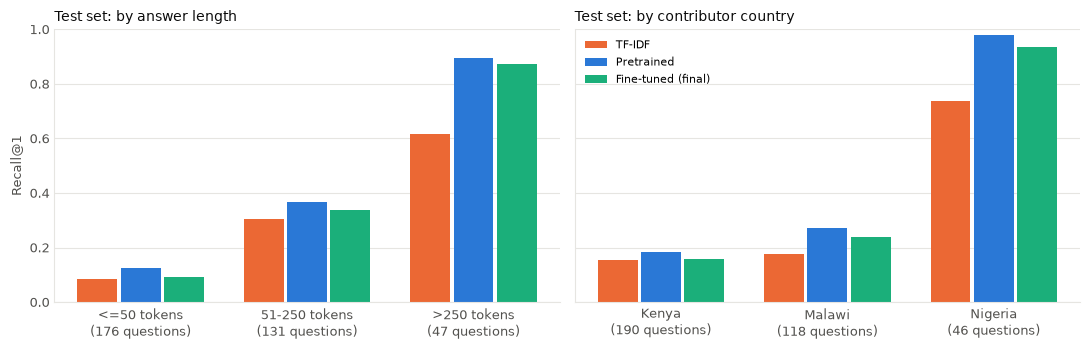

In [6]:
# Recall@1 on the test set by answer length and by country for the three models.
test_groups = breakdown[breakdown.split == "test"]
panels = [("answer length", ["<=50 tokens", "51-250 tokens", ">250 tokens"], "By answer length"),
          ("country", ["KE", "MW", "NG"], "By contributor country")]
labels = {"KE": "Kenya", "MW": "Malawi", "NG": "Nigeria"}
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, (group, values, title) in zip(axes, panels):
    part = test_groups[test_groups.group == group].set_index("value").loc[values]
    x = np.arange(len(values))
    for k, (column, name, color) in enumerate([("TF-IDF", "TF-IDF", ORANGE), ("pretrained", "Pretrained", BLUE),
                                           ("fine-tuned (final)", "Fine-tuned (final)", AQUA)]):
        ax.bar(x + (k - 1) * 0.26, part[column], width=0.24, color=color, label=name)
    ax.set_xticks(x, [f"{labels.get(v, v)}\n({n} questions)" for v, n in zip(values, part.questions)], fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_title(f"Test set: {title.lower()}", loc="left", fontsize=10, color=INK)
    tidy(ax, "y")
axes[0].set_ylabel("Recall@1", fontsize=9, color=INK2)
axes[1].legend(frameon=False, fontsize=8, loc="upper left")
fig.tight_layout(); fig.savefig(RESULTS_DIR / "figures" / "recall_by_group.png", dpi=200); plt.show()

Answer length turned out to be the strongest factor. On the test set, the final model ranked the correct answer first for only 9.1% of the questions whose answers have 50 tokens or fewer, but for 87.2% of those whose answers are longer than 250 tokens. A short answer such as "Propanolol" or "Anti-CCP" carries very little meaning of its own to match against the question, whereas a long answer usually restates its topic.

The differences between countries follow the same pattern. Nigerian expert questions reached a Recall@1 of 0.935, but Kenyan questions reached only 0.158, and the median answer length explains why: Nigerian expert answers have a median of 328.5 tokens, compared with 47.5 for Kenya and 32 for Malawi. The country effect therefore appears to reflect the style of the answers rather than their medical content. The specialties show a similar contrast, with a Recall@1 of 0.973 for Obstetrics and Gynaecology, whose answers have a median of 335 tokens, and 0.057 for Internal Medicine, whose median is 21 tokens. Very long questions of more than 20 words were also hard (0.075), because most of them are clinical case descriptions in which the answer depends on a single detail.

On the validation set, fine-tuning helped most with short questions of 6 to 12 words, where Recall@1 rose from 0.491 to 0.764, which is the crowdsourced style the model was trained on. On the test set, the final model scored slightly below the pretrained model in almost every group. The loss is therefore spread across the test set rather than concentrated in one topic, which agrees with the specialisation found in notebook 03.

## How Far Away Was the Correct Answer?

A wrong top answer can be a near miss, with the correct answer in second or third place, or a complete miss, with the correct answer far down the ranking. Separating these cases shows whether a model was close or had misunderstood the question.

In [7]:
rows = []
for (e, s), p in pred.items():
    r = p.rank_of_correct_answer
    rows.append({"model": EXPERIMENTS[e], "split": s, "rank 1 (correct)": (r == 1).mean(), "rank 2-3 (near miss)": r.between(2, 3).mean(),
                 "rank 4-10": r.between(4, 10).mean(), "rank > 10": (r > 10).mean()})
pd.DataFrame(rows).round(3).sort_values(["split", "model"])

,model,split,rank 1 (correct),rank 2-3 (near miss),rank 4-10,rank > 10
2,TF-IDF,paraphrase,0.075,0.175,0.225,0.525
8,fine-tuned (final),paraphrase,0.450,0.150,0.100,0.300
5,pretrained,paraphrase,0.475,0.125,0.100,0.300
1,TF-IDF,test,0.237,0.088,0.085,0.590
7,fine-tuned (final),test,0.285,0.110,0.150,0.455
4,pretrained,test,0.316,0.107,0.102,0.475
0,TF-IDF,val,0.553,0.156,0.142,0.149
6,fine-tuned (final),val,0.766,0.128,0.057,0.050
3,pretrained,val,0.624,0.170,0.099,0.106


The final model's test errors are mostly complete misses. For 45.5% of the test questions the correct answer is not even in the top 10, while only 11.0% are near misses. The validation set looks very different, with only 5.0% complete misses, so the test errors are real misunderstandings rather than small ranking mistakes.

## Reading Representative Examples

Numbers alone do not show what the errors look like, so we now read examples produced by the final model. In the printed examples, `top1_matched_question` is the dataset question that belongs to the retrieved answer, and `correct_answer` is the answer the model should have returned. For correct predictions, the matched question is naturally the question itself.

In [8]:
def show(df, n, title, cols=("question", "top1_matched_question", "top1_answer", "correct_answer"), seed=SEED):
    print(f"{title} ({len(df)} in total, showing {min(n, len(df))})")
    for _, r in df.sample(min(n, len(df)), random_state=seed).iterrows():
        extra = f"rank of correct answer: {r.rank_of_correct_answer} | score {r.top1_score:.2f}" if "rank_of_correct_answer" in r else ""
        print(extra)
        for c in cols:
            if c in r and isinstance(r[c], str):
                print(f"  {c:>22}: {textwrap.shorten(r[c], 160)}")
        print()

test, val, para = pred[(FINAL, "test")], pred[(FINAL, "val")], pred[(FINAL, "paraphrase")]
show(pd.concat([val[val.correct_at_1], test[test.correct_at_1]]), 4, "Correct (rank 1)")

Correct (rank 1) (209 in total, showing 4)
rank of correct answer: 1 | score 0.76
                question: What local practices in Africa are used for promoting eye health?
   top1_matched_question: What local practices in Africa are used for promoting eye health?
             top1_answer: Africans may use herbs like bilberry, marigold, and African red bush tea (rooibos) to support eye health, as well as consuming foods rich in vitamin A [...]
          correct_answer: Africans may use herbs like bilberry, marigold, and African red bush tea (rooibos) to support eye health, as well as consuming foods rich in vitamin A [...]

rank of correct answer: 1 | score 0.71
                question: What is acute severe asthma
   top1_matched_question: What is acute severe asthma
             top1_answer: Acute severe asthma, also known as status asthmaticus, is a life-threatening medical emergency characterized by: 1. Severe asthma symptoms that don't [...]
          correct_answer: Acute severe

In [9]:
show(pd.concat([val, test])[lambda d: d.rank_of_correct_answer.between(2, 3)], 4, 'Partially relevant: correct answer ranked second or third')

Partially relevant: correct answer ranked second or third (57 in total, showing 4)
rank of correct answer: 2 | score 0.60
                question: How does the presentation of schistosomiasis differ in Africa compared to developed countries?
   top1_matched_question: How does the presentation of schistosomiasis differ between Africa and developed countries?
             top1_answer: In Africa, schistosomiasis may present with more severe symptoms due to higher rates of infection and limited access to healthcare.
          correct_answer: In Africa, schistosomiasis often presents with severe complications such as liver and kidney damage due to factors such as poor sanitation and limited [...]

rank of correct answer: 2 | score 0.69
                question: Which condition is characterized by the accumulation of amyloid protein within the brain and is a common cause of cognitive impairment and dementia in [...]
   top1_matched_question: What is the most common cause of dementia in elde

In [10]:
show(test[test.rank_of_correct_answer > 10], 5, 'Failed on test: correct answer not even in the top 10')

Failed on test: correct answer not even in the top 10 (161 in total, showing 5)
rank of correct answer: 454 | score 0.39
                question: 4 weeks old male presented with projectile non-bilious vomiting for 2 days. What is the likely diagnosis?
   top1_matched_question: List FOUR (4) causes that may result in dehydration and electrolyte loss in this patient ?
             top1_answer: Reduced oral intake Defective intestinal absorption Vomiting Sequestration in the bowel lumen.
          correct_answer: Duodenal atresia

rank of correct answer: 19 | score 0.48
                question: Discuss the following inheritance patterns and recurrence risks associated with it. Give at least one example. X-linked recessive inheritance
   top1_matched_question: Risk factors for colorectal ca
             top1_answer: a) Increasing age b) Family history c) Hereditary syndromes. (Familial adenomatous polyposis, hereditary non polyposis colorectal ca (Lynch syndrome)) d) [...]
          corr

In [11]:
show(para[para.correct_at_1], 3, "Paraphrase answered correctly")
show(para[~para.correct_at_1], 4, "Paraphrase answered wrongly")

Paraphrase answered correctly (18 in total, showing 3)
rank of correct answer: 1 | score 0.65
                question: Can dancing and staying active the traditional way help African communities stay healthy?
   top1_matched_question: How can traditional dance and physical activity be used to promote health and well-being in African communities?
             top1_answer: By incorporating traditional dance and physical activities into health promotion programs, communities can encourage physical fitness and social cohesion.
          correct_answer: By incorporating traditional dance and physical activities into health promotion programs, communities can encourage physical fitness and social cohesion.

rank of correct answer: 1 | score 0.54
                question: How do people usually catch Ebola in Africa?
   top1_matched_question: What is the primary mode of transmission of Ebola virus disease in Africa?
             top1_answer: Ebola virus disease is primarily transmitted throug

## Checking the Refusals

The last group of examples comes from the confidence check in notebook 04. It shows questions that were correctly refused, questions that should have been refused but were answered, and answerable questions that were refused.

In [12]:
decisions = pd.read_csv(RESULTS_DIR / "thresholds" / "decisions_test_final.csv")
def show_decisions(df, n, title):
    print(f"{title} ({len(df)} in total, showing {min(n, len(df))})")
    for _, r in df.sample(min(n, len(df)), random_state=SEED).iterrows():
        print(f"  [{r.category}] {textwrap.shorten(r.question, 110)}\n      score {r.score:.2f} -> {r.decision}"
              + (f" | matched: {textwrap.shorten(r.matched_question, 90)}" if r.decision == "answer" else ""))
    print()
show_decisions(decisions[(decisions.category == "non_medical") & (decisions.decision != "answer")], 4, "Non-medical, correctly refused")
show_decisions(decisions[(decisions.category == "uncovered_medical") & (decisions.decision != "answer")], 4, "Uncovered medical topic, correctly refused")
show_decisions(decisions[(decisions.category.isin(["non_medical", "uncovered_medical"])) & (decisions.decision == "answer")], 6, "Should have been refused but was answered")
show_decisions(decisions[(decisions.category.isin(["in_domain", "paraphrase"])) & (decisions.decision != "answer")], 4, "Answerable but refused")

Non-medical, correctly refused (77 in total, showing 4)
  [non_medical] Who used the church to unify themselves?
      score 0.29 -> outside_scope
  [non_medical] What is one thing that rebellion must have in Black's Law Dictionary?
      score 0.23 -> outside_scope
  [non_medical] How many subscribers were lost within two months of launch from BSkyB?
      score 0.26 -> outside_scope
  [non_medical] What place had the Norman Arab architectural style?
      score 0.17 -> outside_scope

Uncovered medical topic, correctly refused (55 in total, showing 4)
  [uncovered_medical] What underlying conditions or factors could be contributing to my neuropathies? how can they be managed [...]
      score 0.45 -> not_enough_information
  [uncovered_medical] What are the different types of angioedema, and how does their underlying mechanism differ?
      score 0.37 -> not_enough_information
  [uncovered_medical] How do you investigate neuropathy?What is the most effective treatment for neuropathies

  [uncovered_medical] What are the diagnostic tests for Addison's Disease?
      score 0.55 -> answer | matched: Investigations for intestinal obstruction
  [uncovered_medical] What are the non-surgical options for treating a rotator cuff tear?
      score 0.54 -> answer | matched: How do traditional healers in Africa treat fractures?
  [non_medical] What are other common causes of fatalities in dangerous occupations in the world?
      score 0.54 -> answer | matched: Which mosquito-borne disease is a leading cause of death in Africa?
  [uncovered_medical] What daily eye care routine can help manage and prevent blepharitis?
      score 0.55 -> answer | matched: What local practices in Africa are used for promoting eye health?

Answerable but refused (169 in total, showing 4)
  [in_domain] What are the complications of empyema
      score 0.40 -> not_enough_information
  [in_domain] Prognostic indices in breast cancer
      score 0.44 -> not_enough_information
  [in_domain] Describe how

## Common Types of Errors

Reading these examples together reveals a small number of recurring error types. The most common involves very short reference answers. For "From which cells does medullary carcinoma arise?", the correct answer is "Parafollicular cells", which the final model ranked 100th, returning a short answer about tumour markers instead. Linking a question to a one- or two-word answer requires specialised medical knowledge, and a model with 22.7 million parameters trained on 711 pairs often lacks it. Paraphrased questions fail for a related reason. "Which test confirms that someone has rheumatoid arthritis?" has the one-word answer "Anti-CCP", which was ranked 694th because the everyday wording shares nothing with it, whereas paraphrases such as "How do people usually catch Ebola in Africa?" succeed because their answers restate the topic.

A second type of error comes from matching the form of a question rather than its topic. "What are the diagnostic tests for Addison's Disease?" was matched with "Investigations for intestinal obstruction", because both ask for tests, and the same mechanism allowed 4 of the 136 test questions that should have been refused to pass the threshold.

Other errors are less serious or have different causes. When two dataset questions are nearly identical, such as the two questions about how schistosomiasis presents in Africa, the model may return the sibling record's answer, which is compatible with the question but counts as wrong under the strict metric. This is one reason why 57 validation and test questions have their correct answer in second or third place, so Recall@1 slightly underestimates how useful the answers are. Long clinical cases are difficult because the answer depends on details that averaging the token vectors can blur. For the case of a four-week-old baby with projectile non-bilious vomiting, the dataset's reference answer is "Duodenal atresia", although this presentation is classically associated with pyloric stenosis, so the reference answer itself may be debatable. Since only 50 records in the dataset carry expert quality ratings, errors of this kind cannot be ruled out. Finally, some answerable questions were refused because short prompts and abbreviations, such as "What is ANDI and examples" with a score of 0.29, have a low similarity to every answer.

Taken together, these errors point to a few main causes: a small training set drawn from a single crowdsourced source, the shift from crowdsourced to expert questions, very short reference answers, abbreviations, topics the dataset does not cover, and the limited medical knowledge of a small model.

## Testing the Malaria Example From the Brief

The assignment brief uses a malaria question as an example of a paraphrase that the assistant should understand, so we test it directly. The knowledge base contains relevant records, such as the diagnostic test of choice for malaria and the clinical features of malaria in children, but it has no record that simply lists the symptoms of malaria.

In [13]:
from src.assistant import MedicalAssistant
assistant = MedicalAssistant("models/final")
kb = assistant.kb
for q in ["How can someone know they may have malaria?", "What are the symptoms of malaria?"]:
    scores = assistant.retriever.scores([q])[0]
    top = scores.argsort()[::-1][:5]
    print(q, "->", assistant.ask(q)["decision"])
    display(pd.DataFrame({"score": scores[top].round(3), "dataset question of the answer": kb.question.iloc[top].str[:85].values,
                          "answer": kb.answer.iloc[top].str.replace(chr(10), " ").str[:60].values}))

How can someone know they may have malaria? -> answer


,score,dataset question of the answer,answer
0,0.644,What is the commonest parasitic infection in Africa?,Malaria
1,0.472,What are the key differences in the presentation of malaria in African children compa,African children with malaria may present with more severe s
2,0.465,What traditional remedies are commonly used in Africa for treating malaria?,Many Africans use herbs like Artemisia annua (sweet wormwood
3,0.447,What is the diagnostic test of choice for malaria in Nigeria?,Rapid diagnostic tests (RDTs) or microscopy of blood smears.
4,0.429,"Clinical Scenario: A 35-year-old woman presents with fever, headache, and joint pain","The most likely diagnosis is malaria, specifically Plasmodiu"


What are the symptoms of malaria? -> answer


,score,dataset question of the answer,answer
0,0.583,What is the commonest parasitic infection in Africa?,Malaria
1,0.465,What are the key differences in the presentation of malaria in African children compa,African children with malaria may present with more severe s
2,0.418,List 4 common symptoms of peripheral arterial disease,"Pain achiness, fatigue, paresthesia/burning, or discomfort i"
3,0.416,"Which disease, transmitted by the Anopheles mosquito, is a major health burden in Afr","Malaria, transmitted by the Anopheles mosquito, is a major h"
4,0.403,Discuss the clinical features and management of malaria in pediatric patients in Nige,Clinical features of malaria in pediatric patients can vary


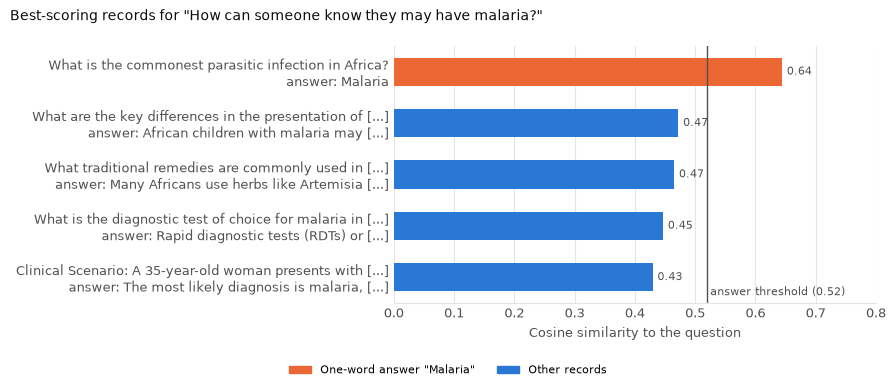

In [14]:
# The five best-scoring records for the first malaria question, with the answer threshold.
from matplotlib.patches import Patch
q = "How can someone know they may have malaria?"
scores = assistant.retriever.scores([q])[0]
top = scores.argsort()[::-1][:5]
names = [textwrap.shorten(kb.question.iloc[t], 58) + "\nanswer: " + textwrap.shorten(kb.answer.iloc[t].replace(chr(10), " "), 44)
         for t in top]
colors = [ORANGE if kb.answer.iloc[t].strip() == "Malaria" else BLUE for t in top]
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.barh(range(5), scores[top], height=0.55, color=colors)
for k, v in enumerate(scores[top]):
    ax.text(v + 0.008, k, f"{v:.2f}", va="center", fontsize=8, color=INK2)
ax.axvline(0.52, color=INK2, linewidth=1)
ax.text(0.525, 4.35, "answer threshold (0.52)", fontsize=8, color=INK2)
ax.set_yticks(range(5), names, fontsize=7.5); ax.invert_yaxis(); ax.set_xlim(0, 0.8)
ax.set_xlabel("Cosine similarity to the question", fontsize=9, color=INK2)
fig.legend(handles=[Patch(color=ORANGE, label='One-word answer "Malaria"'), Patch(color=BLUE, label="Other records")],
           frameon=False, fontsize=8, loc="lower center", ncol=2)
fig.suptitle(f'Best-scoring records for "{q}"', x=0.01, ha="left", fontsize=10, color=INK)
tidy(ax, "x")
fig.tight_layout(rect=(0, 0.07, 1, 1)); fig.savefig(RESULTS_DIR / "figures" / "malaria_example.png", dpi=200); plt.show()

Both questions were answered, but with the wrong record. The one-word answer "Malaria", which belongs to the question "What is the commonest parasitic infection in Africa?", scored 0.644 and 0.583, while the relevant malaria records scored between 0.40 and 0.47, below the answer threshold of 0.52. An answer that consists only of a disease name is similar to almost any question about that disease, so it wins the ranking even though it answers none of them. Without this record, the assistant would have replied that it does not have enough reliable information, which is not ideal either but would at least have avoided a misleading answer.

Answers that are ranked first for many different questions are known as hubs, and they are a known weakness of nearest-neighbour search in high-dimensional spaces. The next cell counts how often each answer was ranked first across all validation and test questions, including those that should be refused.

In [15]:
# Count how often each answer is ranked first across all validation and test questions.
top1 = pd.concat([pd.read_csv(RESULTS_DIR / "thresholds" / f"decisions_{s}_final.csv") for s in ["val", "test"]])
counts = top1.retrieved_answer.value_counts()
print("answers with 3 words or fewer in the knowledge base:", (kb.answer.str.split().str.len() <= 3).sum(), "of", len(kb))
pd.DataFrame({"times ranked first": counts.head(6).values, "words": [len(a.split()) for a in counts.head(6).index],
              "answer": counts.head(6).index.str.replace(chr(10), " ").str[:70]})

answers with 3 words or fewer in the knowledge base: 30 of 1205


,times ranked first,words,answer
0,11,23,patients with acute upper GI bleeding typically have an elevated blood
1,10,6,a. Pancreatic cancer b. Gastric carcinoma
2,10,69,"• TFTs-T3, T4, TSH. Done but does not rule out malignancy • FNAC. diff"
3,10,9,Sigmoid Volvulus - a type of Mechanical Intestinal Obstruction
4,8,13,• Irradiation • Female • Obesity • Family history/hereditary-type 2 ME
5,8,163,1. Laboratory • Pancreatic function tests- serum amylase and lipase el


Only 30 of the 1,205 answers have three words or fewer, so one-word answers are not the main source of hubs. The answers ranked first most often are expert answers of different lengths, such as a 23-word answer about upper gastrointestinal bleeding that was ranked first for 11 different questions, and several list-style answers ranked first 8 to 10 times. Many of them are dense lists of medical terms, which places them close to a wide range of medical questions in the embedding space.

Storing each record as a combined question and answer text was one of the options tested in E6. The next cell checks what this option returns for the two malaria questions.

In [16]:
# Embed each record as one text that combines its question and answer.
docs = assistant.retriever.encode((kb.question + " " + kb.answer).tolist())
for q in ["How can someone know they may have malaria?", "What are the symptoms of malaria?"]:
    s = assistant.retriever.encode([q])[0] @ docs.T
    i = int(s.argmax())
    print(q)
    print(f"   top record ({s[i]:.2f}): {kb.question[i][:90]}")
    print(f"   answer: {kb.answer[i][:90]}")

How can someone know they may have malaria?
   top record (0.48): Clinical Scenario: A 35-year-old woman presents with fever, headache, and joint pain after
   answer: The most likely diagnosis is malaria, specifically Plasmodium falciparum malaria, given th
What are the symptoms of malaria?
   top record (0.44): Clinical Scenario: A 35-year-old woman presents with fever, headache, and joint pain after
   answer: The most likely diagnosis is malaria, specifically Plasmodium falciparum malaria, given th


With the combined text, both malaria questions retrieve a clinical scenario in which the likely diagnosis is malaria, instead of the one-word answer. Its scores of 0.48 and 0.44 are below the current answer threshold, so the thresholds would have to be chosen again for this option. The result supports the future work discussed in notebook 04: storing questions and answers together, giving less weight to answers that are too short to be informative, or adding a second-stage re-ranker, such as a cross-encoder that reads the question and the answer together.

## Summary

The error analysis shows that the final model works best when an answer is a full sentence that restates its topic, which is typical of the crowdsourced records, and worst when an answer is a short list or a single term, which is typical of many expert records. Most test errors are complete misses rather than near misses, and a few answers act as hubs that attract unrelated questions. These findings explain the gap between the validation and test results and point to the most useful improvements: more varied training data that includes expert questions, and a retrieval step that makes better use of both the question and the answer of each record.